# 04 — ARIMA & ARIMAX as Direction Classifiers
**Core idea:** ARIMA/ARIMAX are regression models — they forecast the
*value* of next-day returns. We convert them to classifiers by taking the
**sign of the forecast**:
- Forecast > 0 → predict UP (1)
- Forecast ≤ 0 → predict DOWN (0)

**Walk-forward validation** (refit every 21 trading days on an expanding
window) avoids look-ahead bias and gives a realistic picture of how these
models perform when deployed.

| Model | Inputs |
|---|---|
| ARIMA(1,0,1) | Own past returns only |
| ARIMAX(1,0,1) | Past returns + VIX, 10Y yield, USD Index |


In [1]:
from google.colab import files
files.upload()

Saving gold_silver_final.csv to gold_silver_final.csv


{'gold_silver_final.csv': b'Date,ID_Column,usd_idx,gold,silver,interest,vix,au_returns,ag_returns,au_vol,ag_vol,au_mean,ag_mean,garch_vol_au,garch_vol_ag,vol_regime_au,vol_regime_ag,period_regime,au_lag1,ag_lag1,au_lag2,ag_lag2,au_lag5,ag_lag5,vix_chg,usd_chg,interest_chg,au_ag_ratio,au_ag_ratio_z,garch_vol_au_lag1,garch_vol_ag_lag1,target_au,target_ag\n2010-03-10,5,80.44999694824219,1107.800048828125,16.993999481201172,3.7200000286102295,18.56999969482422,-0.0127366964069781,-0.0188861587895096,0.0102574869504297,0.0176469712480621,0.0018449664888878,0.0056963608433109,0.0082720668889039,0.0136129091073042,low_vol,low_vol,pre_covid,-0.0014249874190179,0.0038183431802686,-0.0099186724609921,-0.0063557561838186,0.0050885588128825,0.0154283259825429,0.03627229998676995,-0.0017371807421538987,0.019000053405761275,65.18771817391061,-0.5787036281619229,0.008444740435278,0.0138647067821398,1,1\n2010-03-11,6,80.31999969482422,1108.0,17.13599967956543,3.7200000286102295,18.059999465942383,0.00

## Setup & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("gold_silver_final.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.sort_index(inplace=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Loaded : {df.shape}")
print(f"Range  : {df.index[0].date()} to {df.index[-1].date()}")


Loaded : (4087, 32)
Range  : 2010-03-10 to 2026-06-12


In [3]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

def evaluate_clf(y_true, y_pred, name, asset):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    print(f"\n  {name} — {asset}")
    print(f"    Accuracy  : {acc:.4f}  |  F1: {f1:.4f}")
    return {"model": name, "asset": asset, "accuracy": acc, "f1": f1}

def regime_eval(results_df, model_name, asset, regime_col):
    print(f"\n  {model_name} | {asset} | by {regime_col}")
    rows = []
    for regime in sorted(results_df[regime_col].unique()):
        sub = results_df[results_df[regime_col] == regime]
        if len(sub) < 10: continue
        acc = accuracy_score(sub["actual"], sub["pred"])
        f1  = f1_score(sub["actual"], sub["pred"], average="weighted", zero_division=0)
        print(f"    {regime:15s} | n={len(sub):4d} | Acc={acc:.4f} | F1={f1:.4f}")
        rows.append({"regime": regime, "n": len(sub), "accuracy": acc, "f1": f1})
    return rows

def run_backtest(results_df, return_col, model_name, asset):
    bt = results_df.copy()
    bt["signal"]    = np.where(bt["pred"] == 1, 1, -1)
    bt["strat_ret"] = bt["signal"] * bt[return_col]
    bt["cum_strat"] = (1 + bt["strat_ret"]).cumprod()
    bt["cum_bh"]    = (1 + bt[return_col]).cumprod()
    total_strat = bt["cum_strat"].iloc[-1] - 1
    total_bh    = bt["cum_bh"].iloc[-1]    - 1
    hit_rate    = (bt["signal"] == (bt[return_col] > 0).map({True:1, False:-1})).mean()
    plt.figure(figsize=(14, 5))
    bt["cum_strat"].plot(label=f"{model_name} L/S Strategy", linewidth=1.5)
    bt["cum_bh"].plot(label="Buy & Hold", linewidth=1.2, linestyle="--", alpha=0.8, color="black")
    plt.axhline(1, color="gray", linewidth=0.6, alpha=0.4)
    plt.title(f"{model_name} — {asset}  |  Strategy: {total_strat:.1%}   B&H: {total_bh:.1%}   Hit Rate: {hit_rate:.1%}", fontweight="bold")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return total_strat, total_bh, hit_rate


## 1. Walk-Forward Engine
Refits ARIMA/ARIMAX every 21 trading days on an expanding window,
then forecasts the next 21 days. Sign of each forecast = direction signal.
This correctly simulates real-time deployment.

In [4]:
ARIMA_ORDER = (1, 0, 1)        # returns are stationary so d=0
EXOG_COLS   = ["vix", "interest", "usd_idx"]
SPLIT       = 0.70
REFIT_EVERY = 21               # refit every ~1 month of trading days

def walk_forward_arima(series, exog=None, order=ARIMA_ORDER,
                        split=SPLIT, refit_every=REFIT_EVERY):
    # Expanding-window walk-forward ARIMA/ARIMAX.
    # Refits every refit_every steps; forecasts next block.
    n         = len(series)
    train_end = int(n * split)
    forecasts = []
    indices   = []
    t = train_end
    while t < n:
        block_end  = min(t + refit_every, n)
        train_y    = series.iloc[:t]
        train_exog = exog.iloc[:t]       if exog is not None else None
        test_exog  = exog.iloc[t:block_end] if exog is not None else None
        try:
            model = ARIMA(train_y, exog=train_exog, order=order)
            fit   = model.fit()
            fc    = fit.forecast(steps=(block_end - t), exog=test_exog)
            forecasts.extend(fc.values)
            indices.extend(series.index[t:block_end])
        except Exception:
            forecasts.extend([0.0] * (block_end - t))
            indices.extend(series.index[t:block_end])
        t = block_end
    return pd.Series(forecasts, index=indices, name="forecast")

print("Walk-forward engine ready.")
print(f"  Order: ARIMA{ARIMA_ORDER}  |  Refit every {REFIT_EVERY} days  |  Split {SPLIT:.0%}")
print(f"  Estimated refits: ~{int((len(df)*(1-SPLIT))/REFIT_EVERY)} per series")

Walk-forward engine ready.
  Order: ARIMA(1, 0, 1)  |  Refit every 21 days  |  Split 70%
  Estimated refits: ~58 per series


## 2. ARIMA — Gold

In [5]:
print("Running ARIMA walk-forward — Gold")
fc_arima_au = walk_forward_arima(df["au_returns"])

pred_arima_au   = (fc_arima_au > 0).astype(int)
actual_arima_au = df.loc[fc_arima_au.index, "target_au"]
vol_reg_au      = df.loc[fc_arima_au.index, "vol_regime_au"]
per_reg_au      = df.loc[fc_arima_au.index, "period_regime"]
ret_au          = df.loc[fc_arima_au.index, "au_returns"]

print("\n=== ARIMA — GOLD (Direction Classification) ===")
print(classification_report(actual_arima_au, pred_arima_au, target_names=["DOWN","UP"]))


Running ARIMA walk-forward — Gold

=== ARIMA — GOLD (Direction Classification) ===
              precision    recall  f1-score   support

        DOWN       0.38      0.01      0.02       556
          UP       0.55      0.99      0.70       671

    accuracy                           0.54      1227
   macro avg       0.47      0.50      0.36      1227
weighted avg       0.47      0.54      0.39      1227



## 3. ARIMA — Silver

In [6]:
print("Running ARIMA walk-forward — Silver")
fc_arima_ag = walk_forward_arima(df["ag_returns"])

pred_arima_ag   = (fc_arima_ag > 0).astype(int)
actual_arima_ag = df.loc[fc_arima_ag.index, "target_ag"]
vol_reg_ag      = df.loc[fc_arima_ag.index, "vol_regime_ag"]
per_reg_ag      = df.loc[fc_arima_ag.index, "period_regime"]
ret_ag          = df.loc[fc_arima_ag.index, "ag_returns"]

print("\n=== ARIMA — SILVER (Direction Classification) ===")
print(classification_report(actual_arima_ag, pred_arima_ag, target_names=["DOWN","UP"]))


Running ARIMA walk-forward — Silver

=== ARIMA — SILVER (Direction Classification) ===
              precision    recall  f1-score   support

        DOWN       0.35      0.03      0.06       584
          UP       0.52      0.95      0.67       643

    accuracy                           0.51      1227
   macro avg       0.44      0.49      0.36      1227
weighted avg       0.44      0.51      0.38      1227



## 4. ARIMAX — Gold (+ Macro Features)

In [7]:
print("Running ARIMAX walk-forward — Gold...")
fc_arimax_au = walk_forward_arima(df["au_returns"], exog=df[EXOG_COLS])

pred_arimax_au   = (fc_arimax_au > 0).astype(int)
actual_arimax_au = df.loc[fc_arimax_au.index, "target_au"]
vol_reg_arimax_au = df.loc[fc_arimax_au.index, "vol_regime_au"]
per_reg_arimax_au = df.loc[fc_arimax_au.index, "period_regime"]

print("\n=== ARIMAX — GOLD (Direction Classification) ===")
print(classification_report(actual_arimax_au, pred_arimax_au, target_names=["DOWN","UP"]))


Running ARIMAX walk-forward — Gold...

=== ARIMAX — GOLD (Direction Classification) ===
              precision    recall  f1-score   support

        DOWN       0.45      0.26      0.33       556
          UP       0.55      0.74      0.63       671

    accuracy                           0.52      1227
   macro avg       0.50      0.50      0.48      1227
weighted avg       0.50      0.52      0.49      1227



## 5. ARIMAX — Silver (+ Macro Features)

In [8]:
print("Running ARIMAX walk-forward — Silver...")
fc_arimax_ag = walk_forward_arima(df["ag_returns"], exog=df[EXOG_COLS])

pred_arimax_ag   = (fc_arimax_ag > 0).astype(int)
actual_arimax_ag = df.loc[fc_arimax_ag.index, "target_ag"]
vol_reg_arimax_ag = df.loc[fc_arimax_ag.index, "vol_regime_ag"]
per_reg_arimax_ag = df.loc[fc_arimax_ag.index, "period_regime"]

print("\n=== ARIMAX — SILVER (Direction Classification) ===")
print(classification_report(actual_arimax_ag, pred_arimax_ag, target_names=["DOWN","UP"]))


Running ARIMAX walk-forward — Silver...

=== ARIMAX — SILVER (Direction Classification) ===
              precision    recall  f1-score   support

        DOWN       0.49      0.53      0.51       584
          UP       0.53      0.49      0.51       643

    accuracy                           0.51      1227
   macro avg       0.51      0.51      0.51      1227
weighted avg       0.51      0.51      0.51      1227



## 6. Forecast Distribution — Sign is the Signal

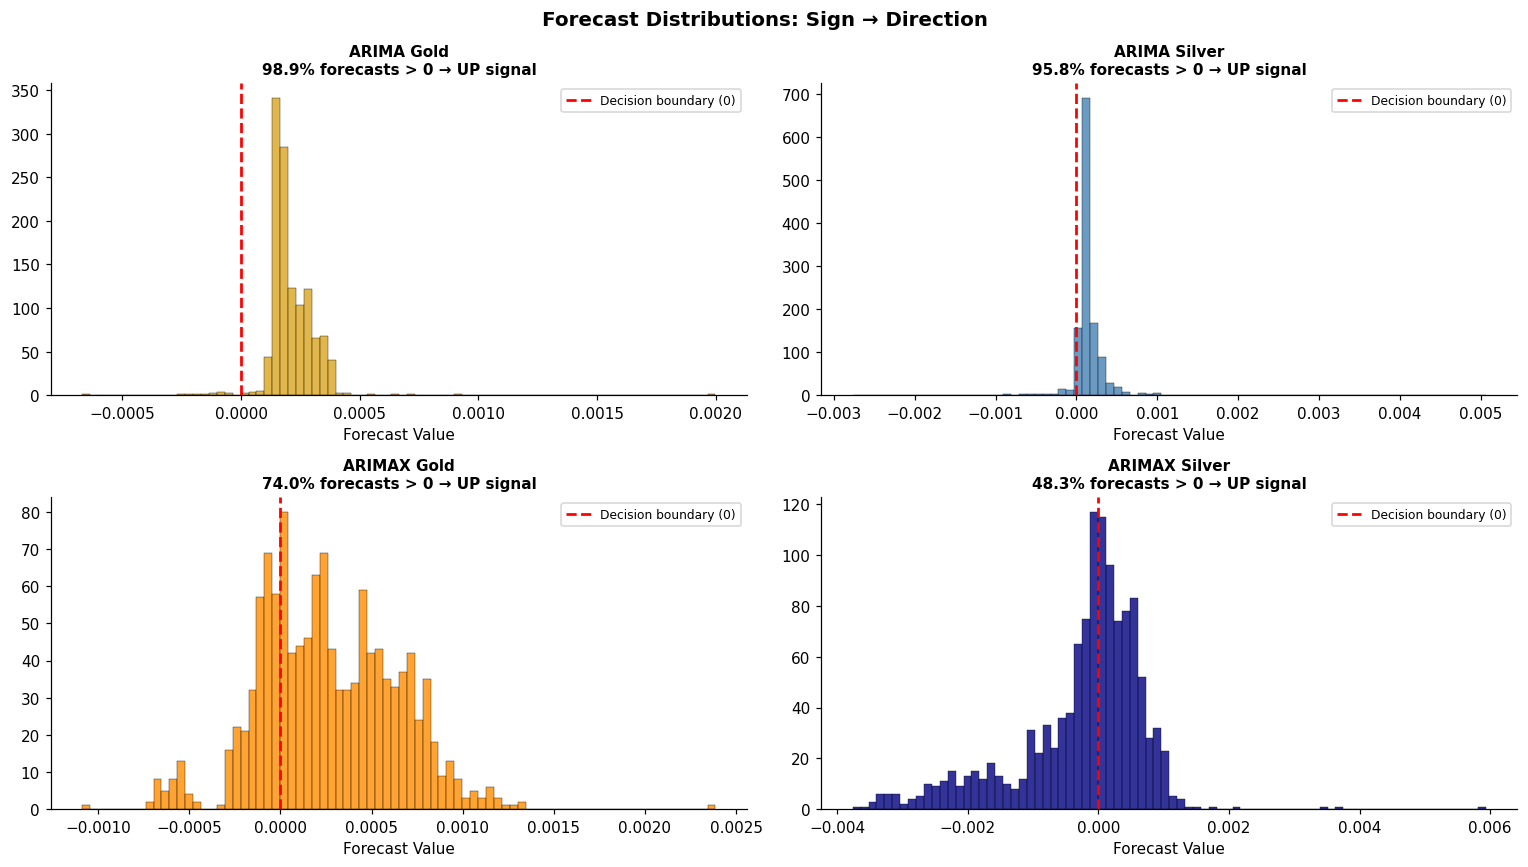

Forecasts cluster near zero — expected for stationary returns.
The key is the SIGN, not the magnitude.


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
pairs = [
    (fc_arima_au,  "ARIMA Gold",    "goldenrod",  axes[0,0]),
    (fc_arima_ag,  "ARIMA Silver",  "steelblue",  axes[0,1]),
    (fc_arimax_au, "ARIMAX Gold",   "darkorange", axes[1,0]),
    (fc_arimax_ag, "ARIMAX Silver", "navy",       axes[1,1]),
]
for fc, title, color, ax in pairs:
    ax.hist(fc, bins=80, color=color, alpha=0.8, edgecolor="black", linewidth=0.3)
    ax.axvline(0, color="red", linewidth=1.8, linestyle="--", label="Decision boundary (0)")
    pct = (fc > 0).mean()
    ax.set_title(f"{title}\n{pct:.1%} forecasts > 0 → UP signal", fontweight="bold", fontsize=10)
    ax.set_xlabel("Forecast Value")
    ax.legend(fontsize=8)
plt.suptitle("Forecast Distributions: Sign → Direction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("Forecasts cluster near zero — expected for stationary returns.")
print("The key is the SIGN, not the magnitude.")


## 7. Confusion Matrices

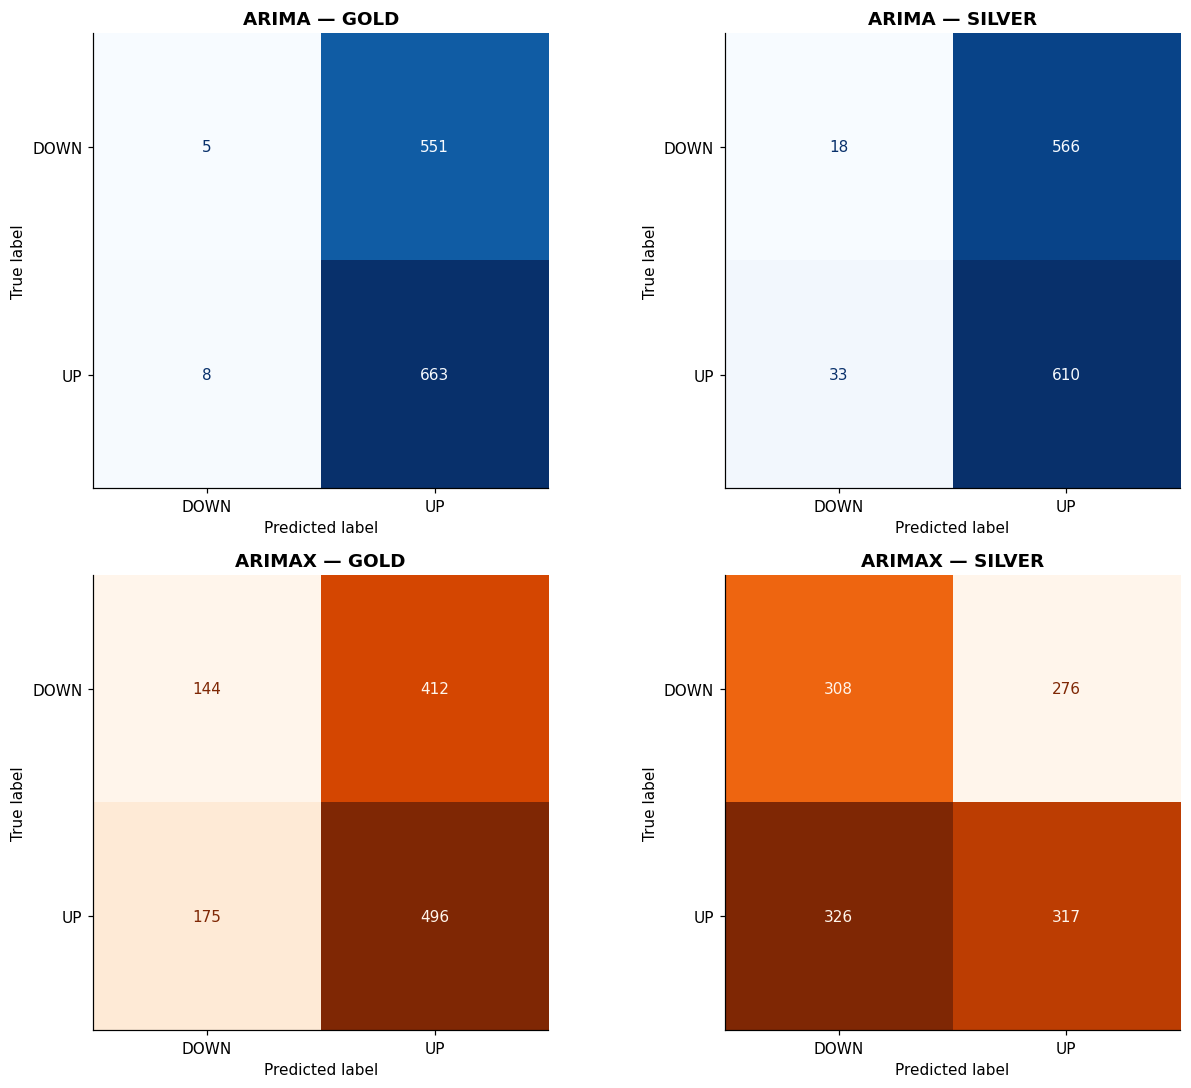

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
pairs = [
    (actual_arima_au,  pred_arima_au,  "ARIMA — GOLD",    "Blues",   axes[0,0]),
    (actual_arima_ag,  pred_arima_ag,  "ARIMA — SILVER",  "Blues",   axes[0,1]),
    (actual_arimax_au, pred_arimax_au, "ARIMAX — GOLD",   "Oranges", axes[1,0]),
    (actual_arimax_ag, pred_arimax_ag, "ARIMAX — SILVER", "Oranges", axes[1,1]),
]
for y_true, y_pred, title, cmap, ax in pairs:
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred), display_labels=["DOWN","UP"]
    ).plot(cmap=cmap, ax=ax, colorbar=False)
    ax.set_title(title, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Regime-Wise Evaluation

In [11]:
# Build result DataFrames
res_arima_au = pd.DataFrame({
    "actual": actual_arima_au.values, "pred": pred_arima_au.values,
    "forecast": fc_arima_au.values, "au_returns": ret_au.values,
    "vol_regime": vol_reg_au.values, "period_regime": per_reg_au.values
}, index=fc_arima_au.index)

res_arima_ag = pd.DataFrame({
    "actual": actual_arima_ag.values, "pred": pred_arima_ag.values,
    "forecast": fc_arima_ag.values, "ag_returns": ret_ag.values,
    "vol_regime": vol_reg_ag.values, "period_regime": per_reg_ag.values
}, index=fc_arima_ag.index)

res_arimax_au = pd.DataFrame({
    "actual": actual_arimax_au.values, "pred": pred_arimax_au.values,
    "forecast": fc_arimax_au.values,
    "au_returns": df.loc[fc_arimax_au.index, "au_returns"].values,
    "vol_regime": vol_reg_arimax_au.values, "period_regime": per_reg_arimax_au.values
}, index=fc_arimax_au.index)

res_arimax_ag = pd.DataFrame({
    "actual": actual_arimax_ag.values, "pred": pred_arimax_ag.values,
    "forecast": fc_arimax_ag.values,
    "ag_returns": df.loc[fc_arimax_ag.index, "ag_returns"].values,
    "vol_regime": vol_reg_arimax_ag.values, "period_regime": per_reg_arimax_ag.values
}, index=fc_arimax_ag.index)

print("=== By Volatility Regime ===")
regime_eval(res_arima_au,  "ARIMA",  "GOLD",   "vol_regime")
regime_eval(res_arima_ag,  "ARIMA",  "SILVER", "vol_regime")
regime_eval(res_arimax_au, "ARIMAX", "GOLD",   "vol_regime")
regime_eval(res_arimax_ag, "ARIMAX", "SILVER", "vol_regime")

print("\n=== By Period Regime ===")
regime_eval(res_arima_au,  "ARIMA",  "GOLD",   "period_regime")
regime_eval(res_arima_ag,  "ARIMA",  "SILVER", "period_regime")
regime_eval(res_arimax_au, "ARIMAX", "GOLD",   "period_regime")
regime_eval(res_arimax_ag, "ARIMAX", "SILVER", "period_regime")


=== By Volatility Regime ===

  ARIMA | GOLD | by vol_regime
    high_vol        | n= 719 | Acc=0.5619 | F1=0.4169
    low_vol         | n= 508 | Acc=0.5197 | F1=0.3589

  ARIMA | SILVER | by vol_regime
    high_vol        | n= 718 | Acc=0.5279 | F1=0.3970
    low_vol         | n= 509 | Acc=0.4892 | F1=0.3526

  ARIMAX | GOLD | by vol_regime
    high_vol        | n= 719 | Acc=0.5382 | F1=0.4749
    low_vol         | n= 508 | Acc=0.4980 | F1=0.4939

  ARIMAX | SILVER | by vol_regime
    high_vol        | n= 718 | Acc=0.5000 | F1=0.5005
    low_vol         | n= 509 | Acc=0.5226 | F1=0.5216

=== By Period Regime ===

  ARIMA | GOLD | by period_regime
    covid           | n= 112 | Acc=0.5446 | F1=0.3935
    post_covid      | n=1115 | Acc=0.5444 | F1=0.3926

  ARIMA | SILVER | by period_regime
    covid           | n= 112 | Acc=0.4732 | F1=0.3415
    post_covid      | n=1115 | Acc=0.5157 | F1=0.3824

  ARIMAX | GOLD | by period_regime
    covid           | n= 112 | Acc=0.5446 | F1=0.3935
 

[{'regime': 'covid',
  'n': 112,
  'accuracy': 0.48214285714285715,
  'f1': 0.4246031746031746},
 {'regime': 'post_covid',
  'n': 1115,
  'accuracy': 0.5121076233183857,
  'f1': 0.5112949247825161}]

## 9. ARIMAX vs ARIMA — Does Macro Help?

In [12]:
print("=== ARIMAX Improvement Over ARIMA ===")
for asset, actual_a, p_arima, p_arimax in [
    ("GOLD",   actual_arima_au, pred_arima_au, pred_arimax_au),
    ("SILVER", actual_arima_ag, pred_arima_ag, pred_arimax_ag),
]:
    acc_a  = accuracy_score(actual_a, p_arima)
    acc_ax = accuracy_score(actual_a, p_arimax)
    f1_a   = f1_score(actual_a, p_arima,  average="weighted", zero_division=0)
    f1_ax  = f1_score(actual_a, p_arimax, average="weighted", zero_division=0)
    verdict = "ARIMAX wins" if acc_ax > acc_a else "ARIMA wins (macro adds noise)"
    print(f"  {asset:6s} | Acc: ARIMA={acc_a:.4f}  ARIMAX={acc_ax:.4f}  delta={acc_ax-acc_a:+.4f}")
    print(f"         | F1 : ARIMA={f1_a:.4f}  ARIMAX={f1_ax:.4f}  delta={f1_ax-f1_a:+.4f}")
    print(f"         | Verdict: {verdict}\n")


=== ARIMAX Improvement Over ARIMA ===
  GOLD   | Acc: ARIMA=0.5444  ARIMAX=0.5216  delta=-0.0228
         | F1 : ARIMA=0.3927  ARIMAX=0.4927  delta=+0.1001
         | Verdict: ARIMA wins (macro adds noise)

  SILVER | Acc: ARIMA=0.5118  ARIMAX=0.5094  delta=-0.0024
         | F1 : ARIMA=0.3785  ARIMAX=0.5095  delta=+0.1311
         | Verdict: ARIMA wins (macro adds noise)



## 10. Backtest

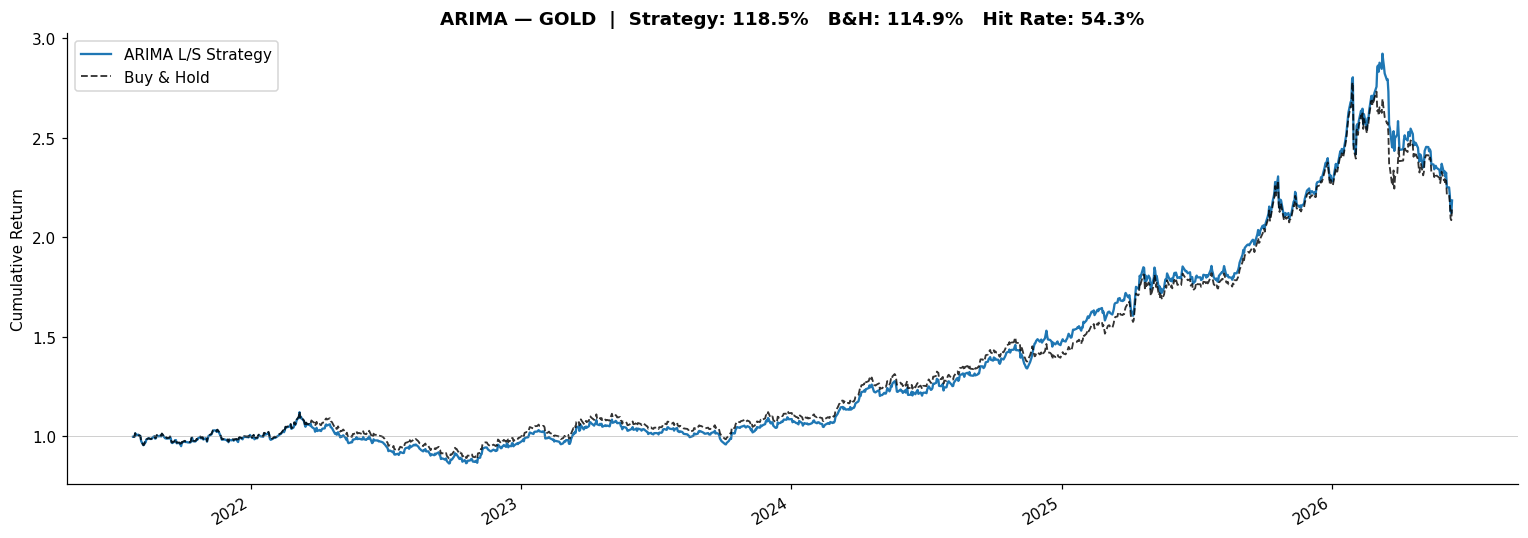

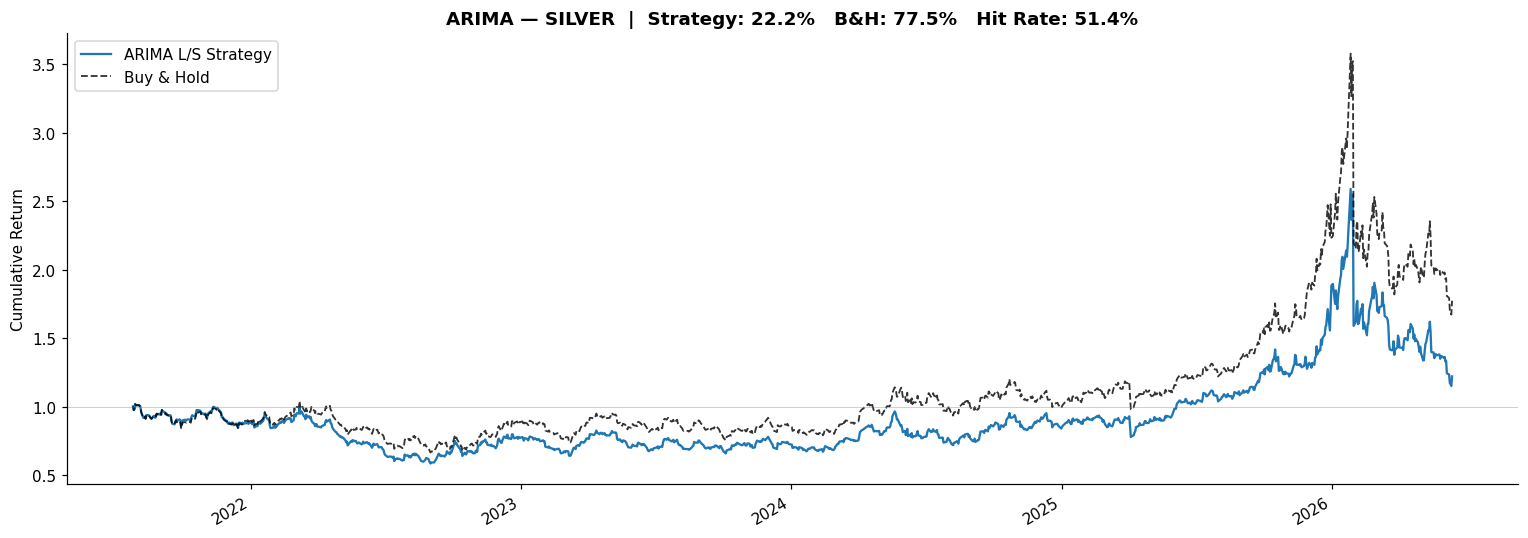

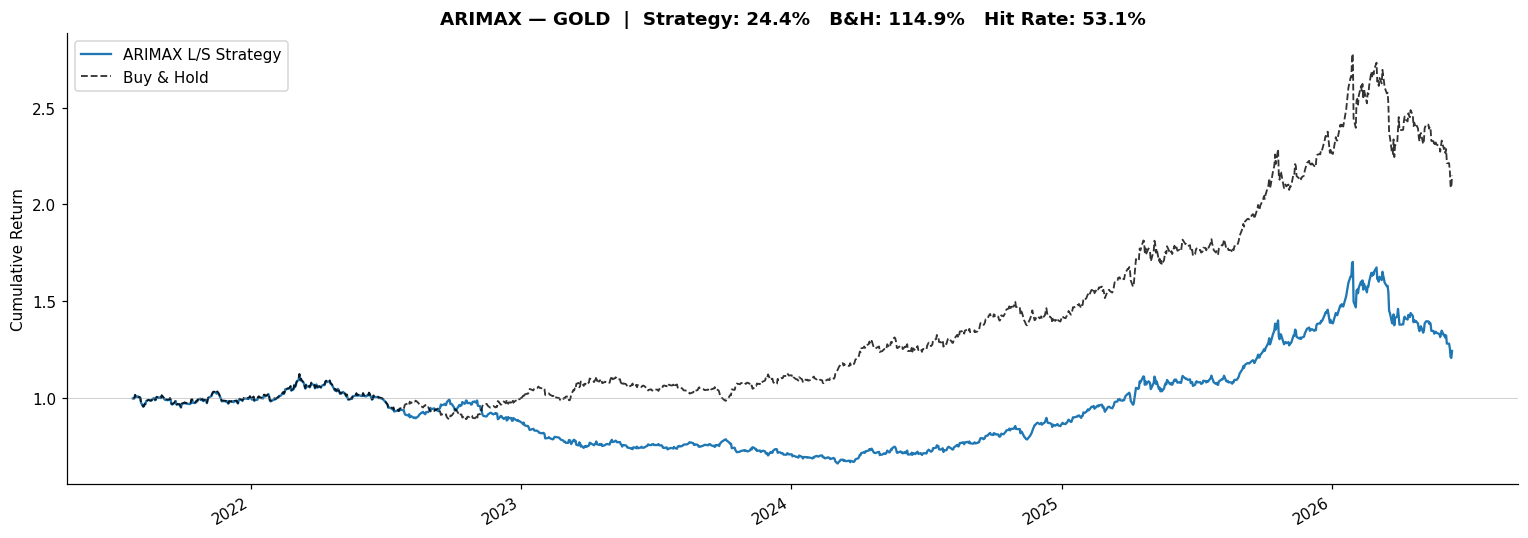

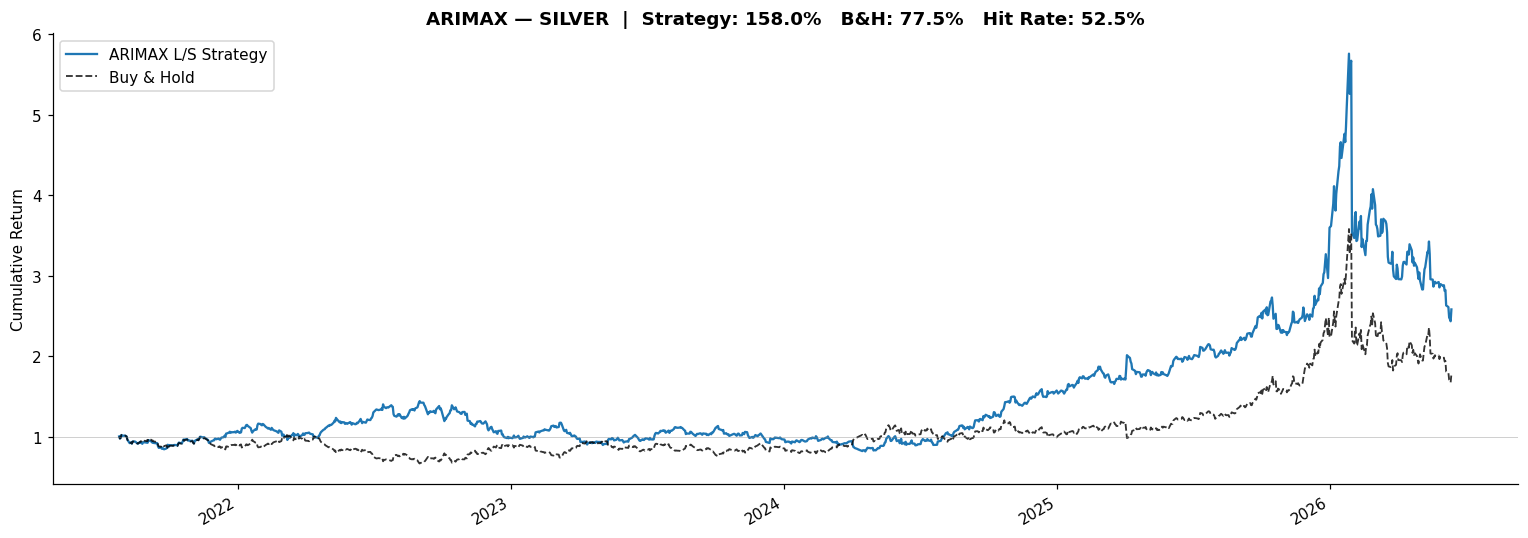

(np.float64(1.5799970365006804),
 np.float64(0.7747004963275068),
 np.float64(0.5248573757131214))

In [13]:
run_backtest(res_arima_au,  "au_returns", "ARIMA",  "GOLD")
run_backtest(res_arima_ag,  "ag_returns", "ARIMA",  "SILVER")
run_backtest(res_arimax_au, "au_returns", "ARIMAX", "GOLD")
run_backtest(res_arimax_ag, "ag_returns", "ARIMAX", "SILVER")


## 11. Actual Returns vs ARIMAX Forecast

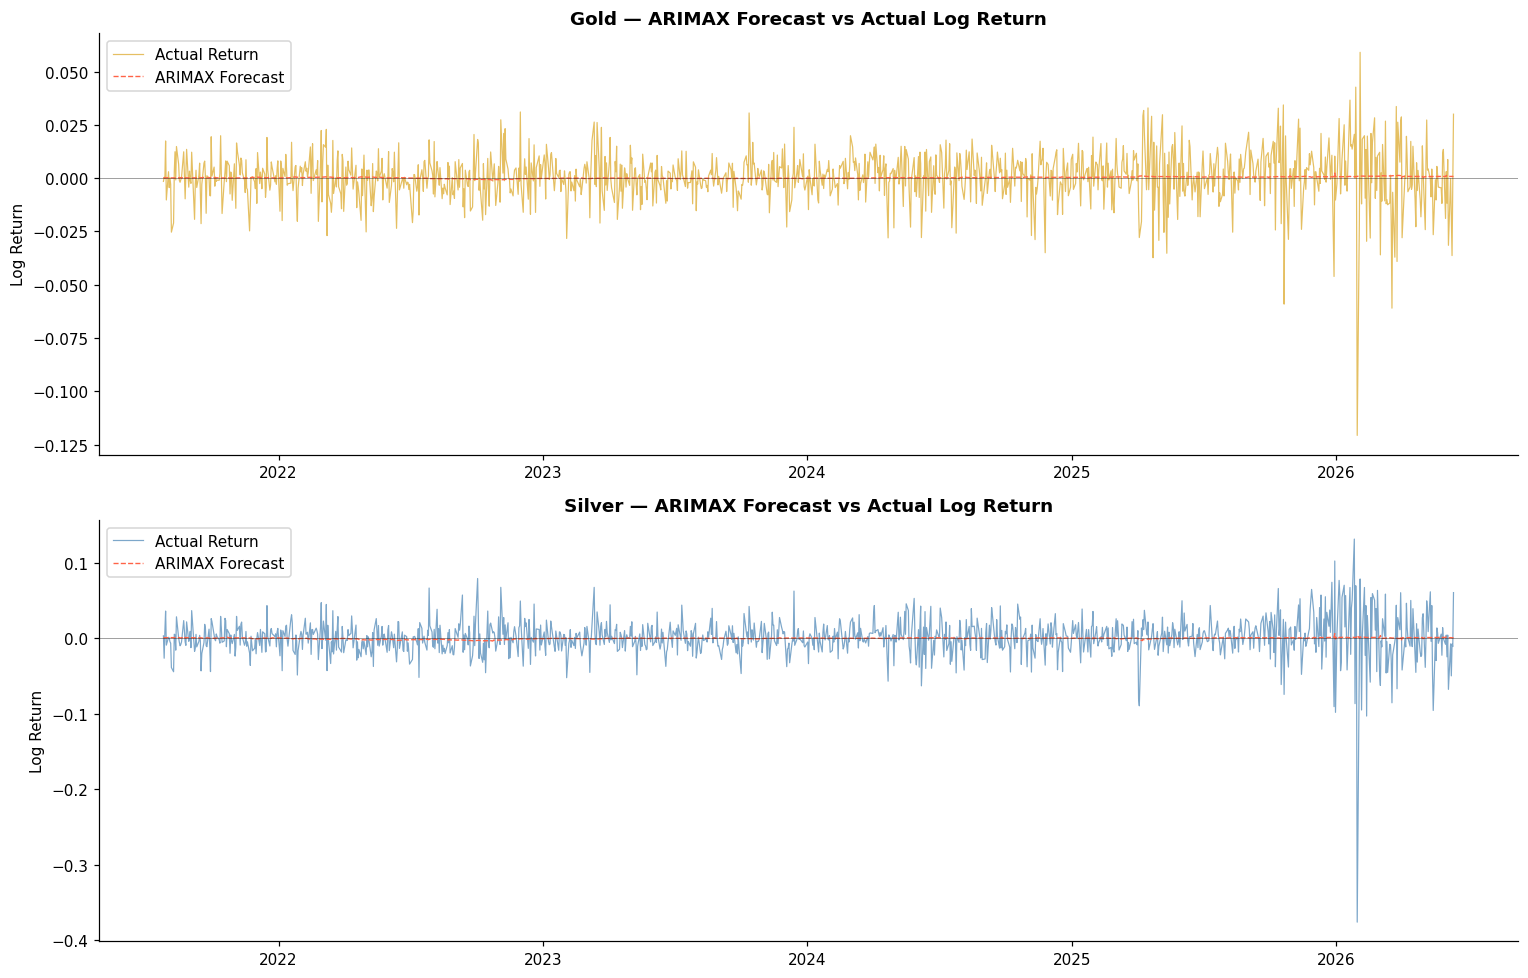

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
for ax, (label, res, ret_col, color) in zip(axes, [
    ("Gold",   res_arimax_au, "au_returns", "goldenrod"),
    ("Silver", res_arimax_ag, "ag_returns", "steelblue"),
]):
    ax.plot(res.index, res[ret_col], color=color, linewidth=0.8, alpha=0.7, label="Actual Return")
    ax.plot(res.index, res["forecast"], color="tomato", linewidth=0.9,
            linestyle="--", label="ARIMAX Forecast")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.4)
    ax.set_title(f"{label} — ARIMAX Forecast vs Actual Log Return", fontweight="bold")
    ax.set_ylabel("Log Return")
    ax.legend()
plt.tight_layout()
plt.show()


## 12. Save Predictions

In [15]:
res_arima_au.to_csv("preds_arima_au.csv")
res_arima_ag.to_csv("preds_arima_ag.csv")
res_arimax_au.to_csv("preds_arimax_au.csv")
res_arimax_ag.to_csv("preds_arimax_ag.csv")
print("Saved: preds_arima_au/ag.csv  preds_arimax_au/ag.csv")


Saved: preds_arima_au/ag.csv  preds_arimax_au/ag.csv


In [16]:
files.download("preds_arima_au.csv")
files.download("preds_arima_ag.csv")
files.download("preds_arimax_au.csv")
files.download("preds_arimax_ag.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>